The notebook creates expert trajectory tensors from hand-labeled data for the 16-prey attack, 32-prey attack, and 16-prey interaction clips. The final dataset consists of 3,747 total windows, saved as expert tensors for model training and evaluation.

### Create Expert Tensors

In [ ]:
# mount + imports
from google.colab import drive
drive.mount('/content/drive')

import os, sys
os.chdir('/content/drive/MyDrive/Predator Prey Thesis')
sys.path.insert(0, '/content/drive/MyDrive/Predator Prey Thesis')

Mounted at /content/drive


In [ ]:
# pip install
!pip install ultralytics
!pip install deep-sort-realtime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 32.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.2/66.2 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 24.3 MB/s eta 0:00:00


In [ ]:
# import necessary libraries
import os
import cv2
import tqdm
import json
import pickle
import numpy as np
import torch
from ultralytics import YOLO
import matplotlib.pyplot as plt
from utils.dataset_utils import *
from collections import defaultdict
from deep_sort_realtime.deepsort_tracker import DeepSort
from pathlib import Path
import glob

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.


In [ ]:
# define paths
data_folder = Path('/content/drive/MyDrive/Predator Prey Thesis/data/1. Data Processing/Raw')
tensor_folder = Path('/content/drive/MyDrive/Predator Prey Thesis/data/1. Data Processing/Processed/video/expert_tensors/windows')

window_len = 10
max_prey = 32

pred_tensors_list = []
prey_tensors_list = []

# recursively find every json file in both subfolders
json_files = sorted(
    glob.glob(os.path.join(data_folder, "pred_prey_interaction/pred_prey_interaction_16", "*.json")) +
    glob.glob(os.path.join(data_folder, "pred_attack/pred_attack_16", "*.json")) +
    glob.glob(os.path.join(data_folder, "pred_attack/pred_attack_32", "*.json"))
)
print(f"Found {len(json_files)} json files")

# process each json file in the data folder
for file_path in json_files:
    file = os.path.basename(file_path)

    # load raw points data
    with open(file_path, 'r') as f:
        data = json.load(f)

    # this clip's native resolution -> rescale into the canonical 2160 arena
    r0 = data[0]["annotations"][0]["result"][0]
    res = {(r["original_width"], r["original_height"])
           for frame in data for r in frame["annotations"][0]["result"]}
    assert len(res) == 1, f"{file}: mixed resolutions {res}"
    s = np.array([2160.0 / r0["original_width"], 2160.0 / r0["original_height"]])

    # scale data points and separate predators and preys
    pairs = [scale_data(pts) for pts in data]
    pred_pts = [p * s for p, _ in pairs]
    prey_pts = [q * s for _, q in pairs]

    # assign identities using Hungarian algorithm
    pred_ordered = hungarian_assign(pred_pts)
    prey_ordered = hungarian_assign(prey_pts)

    # compute velocities for agents from assigned positions
    pred_velocities = get_velocity(pred_ordered)
    prey_velocities = get_velocity(prey_ordered)

    # get records for expert tensors (same format as video pipeline)
    records = get_records(pred_ordered, prey_ordered, pred_velocities, prey_velocities)

    # convert records into expert tensors
    pred_tensor, prey_tensor = get_hl_expert_tensors(records, max_speed=25)

    # skip files that produced no usable frames
    if pred_tensor.numel() == 0:
        print(f"Skipping {file}: no usable frames")
        continue

    n_prey_this_file = prey_tensor.shape[1]
    print(f"{file}: {n_prey_this_file} prey")

    # pad up to max_prey neighbor/agent slots and add the active mask channel
    pred_tensor, prey_tensor = pad_expert_tensors(pred_tensor, prey_tensor, max_prey=max_prey)

    # extract windows from tensors
    pred_windows = extract_tensor_windows(pred_tensor, window_len=window_len)
    prey_windows = extract_tensor_windows(prey_tensor, window_len=window_len)

    pred_tensors_list.append(pred_windows)
    prey_tensors_list.append(prey_windows)

# concatenate all windows from all files
pred_tensors = torch.cat(pred_tensors_list, dim=0)
prey_tensors = torch.cat(prey_tensors_list, dim=0)

# add flag feature to prey tensor (marks neighbor slot 0 as the predator)
n, window, agents, neighs, feature = prey_tensors.shape
flag = torch.zeros((n, window, agents, neighs, 1), dtype=prey_tensors.dtype, device=prey_tensors.device)
flag[:, :, :, 0, 0] = 1
flag = flag * prey_tensors[..., -2:-1] # only on active rows
prey_tensors = torch.cat([flag, prey_tensors], dim=-1)

# save tensors
os.makedirs(os.path.join(tensor_folder, f"{window_len} windows"), exist_ok=True)
pred_path = os.path.join(tensor_folder, f"{window_len} windows", f"pred_tensors_hl_w{window_len}_n{len(pred_tensors)}.pkl")
prey_path = os.path.join(tensor_folder, f"{window_len} windows", f"prey_tensors_hl_w{window_len}_n{len(prey_tensors)}.pkl")
torch.save(pred_tensors, pred_path)
torch.save(prey_tensors, prey_path)

print("Pred Tensors Shape:", tuple(pred_tensors.shape))
print("Prey Tensors Shape:", tuple(prey_tensors.shape))

Found 67 json files
pred_attack_10_16.json: 16 prey
pred_attack_11_16.json: 16 prey
pred_attack_12_16.json: 16 prey
pred_attack_13_16.json: 16 prey
pred_attack_14_16.json: 16 prey
pred_attack_15_16.json: 16 prey
pred_attack_16_16.json: 16 prey
pred_attack_17_16.json: 16 prey
pred_attack_18_16.json: 16 prey
pred_attack_19_16.json: 16 prey
pred_attack_1_16.json: 16 prey
pred_attack_20_16.json: 16 prey
pred_attack_21_16.json: 16 prey
pred_attack_22_16.json: 16 prey
pred_attack_23_16.json: 16 prey
pred_attack_24_16.json: 16 prey
pred_attack_25_16.json: 16 prey
pred_attack_26_16.json: 16 prey
pred_attack_27_16.json: 16 prey
pred_attack_2_16.json: 16 prey
pred_attack_3_16.json: 16 prey
pred_attack_4_16.json: 16 prey
pred_attack_5_16.json: 16 prey
pred_attack_6_16.json: 16 prey
pred_attack_7_16.json: 16 prey
pred_attack_8_16.json: 16 prey
pred_attack_9_16.json: 16 prey
pred_attack_1.json: 32 prey
pred_attack_10.json: 32 prey
pred_attack_11.json: 32 prey
pred_attack_12.json: 32 prey
pred_attac

32 prey and 16 prey attack and 16 prey interaction:

Pred Tensors Shape: (3747, 10, 1, 32, 6)

Prey Tensors Shape: (3747, 10, 32, 32, 7)

### Calculate Speeds

**Create Atack Only Tensors**

In [ ]:
# define paths
data_folder = Path('/content/drive/MyDrive/Predator Prey Thesis/data/1. Data Processing/Raw')
tensor_folder = Path('/content/drive/MyDrive/Predator Prey Thesis/data/1. Data Processing/Processed/video/expert_tensors/windows')

window_len = 10
max_prey = 32

pred_tensors_list = []
prey_tensors_list = []

# recursively find every json file in both subfolders
json_files = sorted(
    glob.glob(os.path.join(data_folder, "pred_attack/pred_attack_16", "*.json")) +
    glob.glob(os.path.join(data_folder, "pred_attack/pred_attack_32", "*.json"))
)
print(f"Found {len(json_files)} json files")

# process each json file in the data folder
for file_path in json_files:
    file = os.path.basename(file_path)

    # load raw points data
    with open(file_path, 'r') as f:
        data = json.load(f)

    # this clip's native resolution -> rescale into the canonical 2160 arena
    r0 = data[0]["annotations"][0]["result"][0]
    res = {(r["original_width"], r["original_height"])
           for frame in data for r in frame["annotations"][0]["result"]}
    assert len(res) == 1, f"{file}: mixed resolutions {res}"
    s = np.array([2160.0 / r0["original_width"], 2160.0 / r0["original_height"]])

    # scale data points and separate predators and preys
    pairs = [scale_data(pts) for pts in data]
    pred_pts = [p * s for p, _ in pairs]
    prey_pts = [q * s for _, q in pairs]

    # assign identities using Hungarian algorithm
    pred_ordered = hungarian_assign(pred_pts)
    prey_ordered = hungarian_assign(prey_pts)

    # compute velocities for agents from assigned positions
    pred_velocities = get_velocity(pred_ordered)
    prey_velocities = get_velocity(prey_ordered)

    # get records for expert tensors (same format as video pipeline)
    records = get_records(pred_ordered, prey_ordered, pred_velocities, prey_velocities)

    # convert records into expert tensors
    pred_tensor, prey_tensor = get_hl_expert_tensors(records, max_speed=25)

    # skip files that produced no usable frames
    if pred_tensor.numel() == 0:
        print(f"Skipping {file}: no usable frames")
        continue

    n_prey_this_file = prey_tensor.shape[1]
    print(f"{file}: {n_prey_this_file} prey")

    # pad up to max_prey neighbor/agent slots and add the active mask channel
    pred_tensor, prey_tensor = pad_expert_tensors(pred_tensor, prey_tensor, max_prey=max_prey)

    # extract windows from tensors
    pred_windows = extract_tensor_windows(pred_tensor, window_len=window_len)
    prey_windows = extract_tensor_windows(prey_tensor, window_len=window_len)

    pred_tensors_list.append(pred_windows)
    prey_tensors_list.append(prey_windows)

# concatenate all windows from all files
pred_tensors = torch.cat(pred_tensors_list, dim=0)
prey_tensors = torch.cat(prey_tensors_list, dim=0)

# add flag feature to prey tensor (marks neighbor slot 0 as the predator)
n, window, agents, neighs, feature = prey_tensors.shape
flag = torch.zeros((n, window, agents, neighs, 1), dtype=prey_tensors.dtype, device=prey_tensors.device)
flag[:, :, :, 0, 0] = 1
flag = flag * prey_tensors[..., -2:-1] # only on active rows
prey_tensors = torch.cat([flag, prey_tensors], dim=-1)

# save tensors
os.makedirs(os.path.join(tensor_folder, f"{window_len} windows (split by attack or interaction -- used for calculating speed)"), exist_ok=True)
pred_path = os.path.join(tensor_folder, f"{window_len} windows (split by attack or interaction -- used for calculating speed)", f"pred_tensors_hl_attack_w{window_len}_n{len(pred_tensors)}.pkl")
prey_path = os.path.join(tensor_folder, f"{window_len} windows (split by attack or interaction -- used for calculating speed)", f"prey_tensors_hl_attack_w{window_len}_n{len(prey_tensors)}.pkl")
torch.save(pred_tensors, pred_path)
torch.save(prey_tensors, prey_path)

print("Pred Tensors Shape:", tuple(pred_tensors.shape))
print("Prey Tensors Shape:", tuple(prey_tensors.shape))

Found 59 json files
pred_attack_10_16.json: 16 prey
pred_attack_11_16.json: 16 prey
pred_attack_12_16.json: 16 prey
pred_attack_13_16.json: 16 prey
pred_attack_14_16.json: 16 prey
pred_attack_15_16.json: 16 prey
pred_attack_16_16.json: 16 prey
pred_attack_17_16.json: 16 prey
pred_attack_18_16.json: 16 prey
pred_attack_19_16.json: 16 prey
pred_attack_1_16.json: 16 prey
pred_attack_20_16.json: 16 prey
pred_attack_21_16.json: 16 prey
pred_attack_22_16.json: 16 prey
pred_attack_23_16.json: 16 prey
pred_attack_24_16.json: 16 prey
pred_attack_25_16.json: 16 prey
pred_attack_26_16.json: 16 prey
pred_attack_27_16.json: 16 prey
pred_attack_2_16.json: 16 prey
pred_attack_3_16.json: 16 prey
pred_attack_4_16.json: 16 prey
pred_attack_5_16.json: 16 prey
pred_attack_6_16.json: 16 prey
pred_attack_7_16.json: 16 prey
pred_attack_8_16.json: 16 prey
pred_attack_9_16.json: 16 prey
pred_attack_1.json: 32 prey
pred_attack_10.json: 32 prey
pred_attack_11.json: 32 prey
pred_attack_12.json: 32 prey
pred_attac

32 prey and 16 prey attack:

Pred Tensors Shape: (2200, 10, 1, 32, 6)

Prey Tensors Shape: (2200, 10, 32, 32, 7)

**Create Iteraction Only Tensors**

In [ ]:
# define paths
data_folder = Path('/content/drive/MyDrive/Predator Prey Thesis/data/1. Data Processing/Raw')
tensor_folder = Path('/content/drive/MyDrive/Predator Prey Thesis/data/1. Data Processing/Processed/video/expert_tensors/windows')

window_len = 10
max_prey = 32

pred_tensors_list = []
prey_tensors_list = []

# recursively find every json file in both subfolders
json_files = sorted(
    glob.glob(os.path.join(data_folder, "pred_prey_interaction/pred_prey_interaction_16", "*.json"))
)
print(f"Found {len(json_files)} json files")

# process each json file in the data folder
for file_path in json_files:
    file = os.path.basename(file_path)

    # load raw points data
    with open(file_path, 'r') as f:
        data = json.load(f)

    # this clip's native resolution -> rescale into the canonical 2160 arena
    r0 = data[0]["annotations"][0]["result"][0]
    res = {(r["original_width"], r["original_height"])
           for frame in data for r in frame["annotations"][0]["result"]}
    assert len(res) == 1, f"{file}: mixed resolutions {res}"
    s = np.array([2160.0 / r0["original_width"], 2160.0 / r0["original_height"]])

    # scale data points and separate predators and preys
    pairs = [scale_data(pts) for pts in data]
    pred_pts = [p * s for p, _ in pairs]
    prey_pts = [q * s for _, q in pairs]

    # assign identities using Hungarian algorithm
    pred_ordered = hungarian_assign(pred_pts)
    prey_ordered = hungarian_assign(prey_pts)

    # compute velocities for agents from assigned positions
    pred_velocities = get_velocity(pred_ordered)
    prey_velocities = get_velocity(prey_ordered)

    # get records for expert tensors (same format as video pipeline)
    records = get_records(pred_ordered, prey_ordered, pred_velocities, prey_velocities)

    # convert records into expert tensors
    pred_tensor, prey_tensor = get_hl_expert_tensors(records, max_speed=25)

    # skip files that produced no usable frames
    if pred_tensor.numel() == 0:
        print(f"Skipping {file}: no usable frames")
        continue

    n_prey_this_file = prey_tensor.shape[1]
    print(f"{file}: {n_prey_this_file} prey")

    # pad up to max_prey neighbor/agent slots and add the active mask channel
    pred_tensor, prey_tensor = pad_expert_tensors(pred_tensor, prey_tensor, max_prey=max_prey)

    # extract windows from tensors
    pred_windows = extract_tensor_windows(pred_tensor, window_len=window_len)
    prey_windows = extract_tensor_windows(prey_tensor, window_len=window_len)

    pred_tensors_list.append(pred_windows)
    prey_tensors_list.append(prey_windows)

# concatenate all windows from all files
pred_tensors = torch.cat(pred_tensors_list, dim=0)
prey_tensors = torch.cat(prey_tensors_list, dim=0)

# add flag feature to prey tensor (marks neighbor slot 0 as the predator)
n, window, agents, neighs, feature = prey_tensors.shape
flag = torch.zeros((n, window, agents, neighs, 1), dtype=prey_tensors.dtype, device=prey_tensors.device)
flag[:, :, :, 0, 0] = 1
flag = flag * prey_tensors[..., -2:-1] # only on active rows
prey_tensors = torch.cat([flag, prey_tensors], dim=-1)

# save tensors
os.makedirs(os.path.join(tensor_folder, f"{window_len} windows (split by attack or interaction -- used for calculating speed)"), exist_ok=True)
pred_path = os.path.join(tensor_folder, f"{window_len} windows (split by attack or interaction -- used for calculating speed)", f"pred_tensors_hl_interaction_w{window_len}_n{len(pred_tensors)}.pkl")
prey_path = os.path.join(tensor_folder, f"{window_len} windows (split by attack or interaction -- used for calculating speed)", f"prey_tensors_hl_interaction_w{window_len}_n{len(prey_tensors)}.pkl")
torch.save(pred_tensors, pred_path)
torch.save(prey_tensors, prey_path)

print("Pred Tensors Shape:", tuple(pred_tensors.shape))
print("Prey Tensors Shape:", tuple(prey_tensors.shape))

Found 8 json files
pred_prey_interaction_11_16.json: 16 prey
pred_prey_interaction_1_16.json: 16 prey
pred_prey_interaction_2_16.json: 16 prey
pred_prey_interaction_3_16.json: 16 prey
pred_prey_interaction_4_16.json: 16 prey
pred_prey_interaction_5_16.json: 16 prey
pred_prey_interaction_6_16.json: 16 prey
pred_prey_interaction_7_16.json: 16 prey
Pred Tensors Shape: (1547, 10, 1, 32, 6)
Prey Tensors Shape: (1547, 10, 32, 32, 7)


16 prey interactions:

Pred Tensors Shape: (1547, 10, 1, 32, 6)

Prey Tensors Shape: (1547, 10, 32, 32, 7)

In [ ]:
W = os.path.join(tensor_folder, "10 windows (split by attack or interaction -- used for calculating speed)")

def prey_speeds(path, label, ms=25.0):

    # load saved prey tensors
    t = torch.load(os.path.join(W, path), weights_only=False)

    # count number of active prey agents in first frame of each window
    n_alive = (t[:, 0, :, :, -2].max(dim=-1).values > 0.5).sum(dim=-1)

    # analyze two prey conditions seperately
    for g in (16, 32):
        sub = t[n_alive == g]
        if not len(sub): continue

        # active mask for all entries in selected windows - prevents padded rows from contributing to the states
        act = sub[..., -2].bool()

        # calculate velocity for every prey neighbor
        mag = (sub[..., 3]**2 + sub[..., 4]**2).sqrt()[act] * ms

        # calculate max active speed in each individual window
        pw = (sub[..., 3]**2 + sub[..., 4]**2).sqrt().amax(dim=(1,2,3)) * ms

        print(
            f"{label}: {g} prey, {len(sub)} windows | "
            f"median={mag.median():.2f}, "
            f"p95={mag.quantile(0.95):.2f}, "
            f"per-window peak median={pw.median():.2f}, "
            f"max={mag.max():.2f}"
        )

prey_speeds("prey_tensors_hl_interaction_w10_n1547.pkl",  "interactions (prey)")
prey_speeds("prey_tensor_w10_n24.pt", "interaction (prey)")
prey_speeds("prey_tensors_hl_attack_w10_n2200.pkl",  "attack (prey)")

interactions (prey): 16 prey, 1547 windows | median=2.87, p95=9.30, per-window peak median=8.02, max=35.36
interaction (prey): 32 prey, 24 windows | median=1.72, p95=3.17, per-window peak median=3.52, max=4.84
attack (prey): 16 prey, 1431 windows | median=3.59, p95=14.43, per-window peak median=19.41, max=35.36
attack (prey): 32 prey, 769 windows | median=5.32, p95=17.58, per-window peak median=31.77, max=35.36


In [ ]:
def pred_speeds(pred_path, prey_path, label, ms=25.0):

    # load pred tensor
    pt = torch.load(os.path.join(W, pred_path), weights_only=False)

    # load corresponding prey tensor - used to determine how many prey are active in each window
    yt = torch.load(os.path.join(W, prey_path), weights_only=False)

    # count number of active prey agents in first frame of each window
    n_alive = (yt[:, 0, :, :, -2].max(dim=-1).values > 0.5).sum(dim=-1)

    # analyze two prey conditions seperately
    for g in (16, 32):
        sub = pt[n_alive == g]
        if not len(sub): continue

        # active mask for all entries in selected windows - prevents padded rows from contributing to the states
        act = sub[..., -2].bool()

        # calculate velocity for every prey neighbor
        mag = (sub[..., 2]**2 + sub[..., 3]**2).sqrt()[act] * ms

        # calculate max active speed in each individual window
        pw = (sub[..., 2]**2 + sub[..., 3]**2).sqrt().amax(dim=(1,2,3)) * ms

        print(
            f"{label}: {g} pred, {len(sub)} windows | "
            f"median={mag.median():.2f}, "
            f"p95={mag.quantile(0.95):.2f}, "
            f"per-window peak median={pw.median():.2f}, "
            f"max={mag.max():.2f}"
        )

pred_speeds("pred_tensors_hl_interaction_w10_n1547.pkl", "prey_tensors_hl_interaction_w10_n1547.pkl", "interaction (pred)")
pred_speeds("pred_tensor_w10_n24.pt", "prey_tensor_w10_n24.pt", "interaction (pred)")
pred_speeds("pred_tensors_hl_attack_w10_n2200.pkl", "prey_tensors_hl_attack_w10_n2200.pkl", "attack (pred)")

interaction (pred): 16 pred, 1547 windows | median=2.89, p95=9.23, per-window peak median=8.02, max=32.68
interaction (pred): 32 pred, 24 windows | median=1.73, p95=3.18, per-window peak median=3.52, max=4.84
attack (pred): 16 pred, 1431 windows | median=3.58, p95=13.96, per-window peak median=18.07, max=35.36
attack (pred): 32 pred, 769 windows | median=5.08, p95=16.84, per-window peak median=25.76, max=35.36


### Quality Analysis of the 16-Prey Trajectories

In [ ]:
# mount + imports
from google.colab import drive
drive.mount('/content/drive')

import os, sys
os.chdir('/content/drive/MyDrive/Predator Prey Thesis')
sys.path.insert(0, '/content/drive/MyDrive/Predator Prey Thesis')

Mounted at /content/drive


In [ ]:
# pip install
!pip install ultralytics
!pip install deep-sort-realtime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.2/66.2 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 32.6 MB/s eta 0:00:00


In [ ]:
# import necessary libraries
import os
import cv2
import tqdm
import json
import pickle
import numpy as np
import torch
from ultralytics import YOLO
import matplotlib.pyplot as plt
from utils.dataset_utils import *
from collections import defaultdict
from deep_sort_realtime.deepsort_tracker import DeepSort
from pathlib import Path
import glob
import re

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.


In [ ]:
# analyze the attack trajectories of the prey

raw = '/content/drive/MyDrive/Predator Prey Thesis/data/1. Data Processing/Raw'

# 1.5 m tank across the 2160 frame size
CM_PER_PX = 150.0 / 2160.0

# 25 fps, every 2nd frame
DT = 0.08

# threshold in pixels of a suspected ID switch
GATE = 120

def get_tracks(file_path):

    # open label studio export
    with open(file_path) as f:
        data = json.load(f)

    # grabs the first annotation
    r0 = data[0]['annotations'][0]['result'][0]

    # scale factor -- map resolution to 2160 × 2160 canonical frame
    s = np.array([2160.0 / r0['original_width'], 2160.0 / r0['original_height']])

    # converts each frame's Label Studio percentages into pixel coordinates and split into predator and prey
    pairs = [scale_data(pts) for pts in data]
    pred = hungarian_assign([p * s for p, _ in pairs])
    prey = hungarian_assign([q * s for _, q in pairs])
    return pred, prey

files = sorted(glob.glob(os.path.join(raw, 'pred_attack/pred_attack_16', '*.json')))
print(f"{'clip':<28}{'N':>4}{'med':>7}{'p99':>7}{'max':>9}{'>gate':>7}")
for fp in files:
    pred, prey = get_tracks(fp)
    d = np.linalg.norm(np.diff(prey, axis=0), axis=2) # (T-1, N) px per step
    print(f"{os.path.basename(fp)[:-5]:<28}{d.shape[1]:>4}{np.median(d):>7.0f}"
          f"{np.percentile(d, 99):>7.0f}{d.max():>9.0f}{(d > GATE).sum():>7d}")

clip                           N    med    p99      max  >gate
pred_attack_10_16             16      5     40       56      0
pred_attack_11_16             16      9     46       53      0
pred_attack_12_16             16      8     38       47      0
pred_attack_13_16             16      6     31       49      0
pred_attack_14_16             16      7     31       40      0
pred_attack_15_16             16      5     25       38      0
pred_attack_16_16             16      5     38       52      0
pred_attack_17_16             16      8     41       61      0
pred_attack_18_16             16      8     41       68      0
pred_attack_19_16             16      5     26       43      0
pred_attack_1_16              16      6     30       43      0
pred_attack_20_16             16      9     40       49      0
pred_attack_21_16             16     11     44       51      0
pred_attack_22_16             16      8     35       45      0
pred_attack_23_16             16      7     33       55

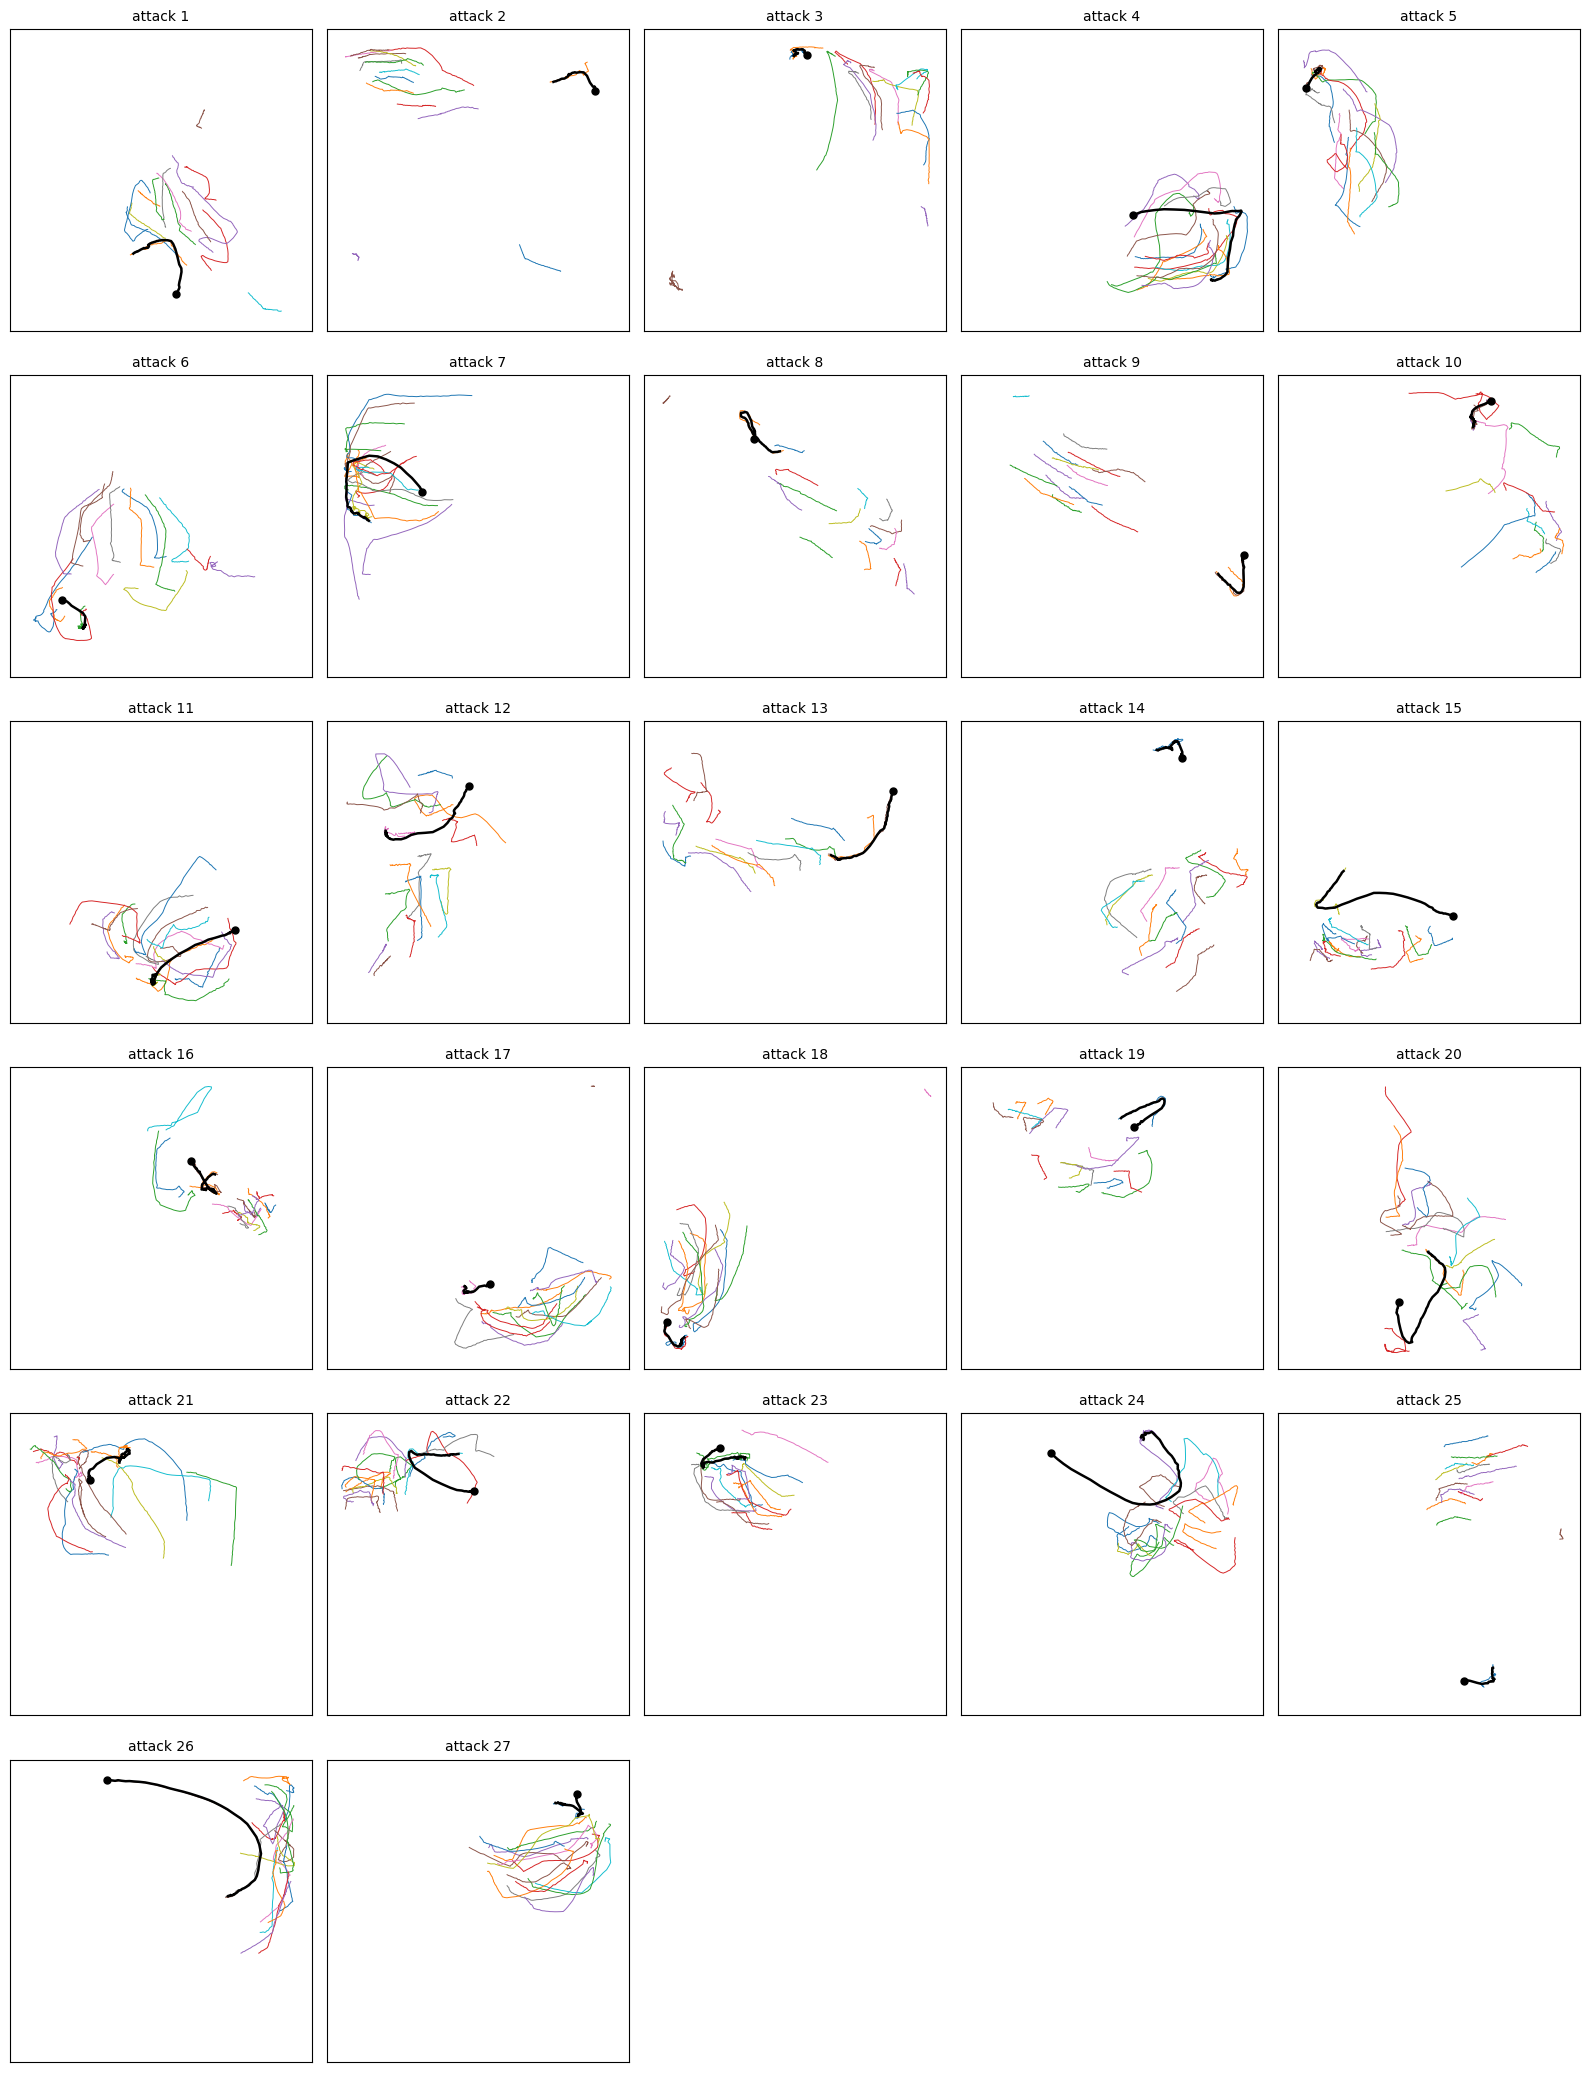

In [ ]:
# visualize the reconstructed trajectories for all the attack clips

import re

files = sorted(glob.glob(os.path.join(raw, 'pred_attack/pred_attack_16', '*.json')),
               key=lambda p: int(re.search(r'pred_attack_(\d+)_16', p).group(1)))

ncols, nrows = 5, 6
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3.2, nrows * 3.5))

for ax, fp in zip(axes.ravel(), files):
    pred, prey = get_tracks(fp)
    d = np.linalg.norm(np.diff(prey, axis=0), axis=2)
    bad = int((d > GATE).sum())
    for i in range(prey.shape[1]):
        ax.plot(prey[:, i, 0], prey[:, i, 1], lw=0.7)

    ax.plot(pred[:, 0, 0], pred[:, 0, 1], 'k-', lw=1.8)
    ax.plot(pred[0, 0, 0], pred[0, 0, 1], 'ko', ms=5)

    ax.set_xlim(0, 2160); ax.set_ylim(2160, 0); ax.set_aspect('equal')
    ax.set_xticks([]); ax.set_yticks([])

    n = re.search(r'pred_attack_(\d+)_16', fp).group(1)
    ax.set_title(f'attack {n}' + (f' — {bad} flagged' if bad else ''),
                 fontsize=10, color='crimson' if bad else 'black')

for ax in axes.ravel()[len(files):]:
    ax.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# analyze the interaction trajectories of the prey

interactions = sorted(glob.glob(os.path.join(raw, 'pred_prey_interaction/pred_prey_interaction_16', '*.json')))

print(f"{'clip':<28}{'N':>4}{'med':>7}{'p99':>7}{'max':>9}{'>gate':>7}")
for fp in interactions:
    pred, prey = get_tracks(fp)
    d = np.linalg.norm(np.diff(prey, axis=0), axis=2) # (T-1, N) px per step
    print(f"{os.path.basename(fp)[:-5]:<28}{d.shape[1]:>4}{np.median(d):>7.0f}"
          f"{np.percentile(d, 99):>7.0f}{d.max():>9.0f}{(d > GATE).sum():>7d}")

clip                           N    med    p99      max  >gate
pred_prey_interaction_11_16   16      5     12       16      0
pred_prey_interaction_1_16    16      8     41       54      0
pred_prey_interaction_2_16    16      9     41       65      0
pred_prey_interaction_3_16    16      5     23       57      0
pred_prey_interaction_4_16    16      6     22       40      0
pred_prey_interaction_5_16    16      5     13       18      0
pred_prey_interaction_6_16    16      8     43       64      0
pred_prey_interaction_7_16    16     10     39       55      0
